# **Team Details**

TEAM Number: 15\
TEAM Members:
1. Hriday Bhuta - 2023A2PS0901H
2. Naman Jindal - 2023AAPS1064H
3. Archit Diwane - 2023A3PS1361H
4. Aryan Agarwal - 2023A5PS1039H

# **Installing Dependencies**

In [1]:
# Necessary dependencies for colab
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn

# **Importing Libraries**

We use only four libraries throughout this notebook:
- **pandas** for loading and inspecting the CSV dataset (DataFrames, `.info()`, `.describe()`).
- **numpy** for all numerical operations: array manipulation, linear algebra, gradient descent, and metric computation.
- **matplotlib** for creating plots (histograms, scatter plots, bar charts, loss curves).
- **seaborn** for statistical visualisations (heatmaps, boxplots, violin plots) built on top of matplotlib.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Understanding and Preprocessing**

**Objective:** Before building any model, we need to thoroughly understand the dataset its structure, types, and quality.

**Steps:**
1. Load and inspect the dataset structure (size, variables, data types).
2. Identify numerical and categorical features.
3. Define a dependent feature as the regression target.
4. Justify the selection of numerical input features.

**Why we we need to do this:**
- Understanding the shape and types helps determine which ML techniques are applicable.
- Checking for missing values and data quality issues is essential before modelling.
- Choosing the right target variable and excluding leaky features (like component GHG gases that directly sum to the target) is critical to ensure the model learns genuine relationships rather than trivial arithmetic identities.


In [3]:
df = pd.read_csv('Dataset.csv')
print(f"Dataset Size: {df.shape}")
print(df.info())
display(df.head())

Dataset Size: (40000, 14)
<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop_Type            40000 non-null  str    
 1   Fertilizer_Type      40000 non-null  str    
 2   Nitrogen_kg_ha       40000 non-null  float64
 3   Irrigation_Method    40000 non-null  str    
 4   Irrigation_Water_mm  40000 non-null  float64
 5   Avg_Temperature_C    40000 non-null  float64
 6   Rainfall_mm          40000 non-null  float64
 7   Humidity_%           40000 non-null  float64
 8   CO2_kg_ha            40000 non-null  float64
 9   CH4_kg_ha            40000 non-null  float64
 10  N2O_kg_ha            40000 non-null  float64
 11  Total_GHG_kgCO2e     40000 non-null  float64
 12  Scenario_Type        40000 non-null  str    
 13  Intervention_Type    30000 non-null  str    
dtypes: float64(9), str(5)
memory usage: 4.3 MB
None


,Crop_Type,Fertilizer_Type,Nitrogen_kg_ha,Irrigation_Method,Irrigation_Water_mm,Avg_Temperature_C,Rainfall_mm,Humidity_%,CO2_kg_ha,CH4_kg_ha,N2O_kg_ha,Total_GHG_kgCO2e,Scenario_Type,Intervention_Type
0,Soybean,Synthetic,232.998485,Sprinkler,798.658484,13.900466,487.193424,42.904181,660.659923,3.832290,2.935502,1631.246917,Baseline,NaN
1,Soybean,Synthetic,141.237938,Sprinkler,713.986285,15.732909,487.193424,42.904181,588.493009,2.439946,1.520592,1102.628022,Counterfactual,Reduced_Input
2,Soybean,Synthetic,161.065486,Sprinkler,642.881174,15.332411,487.193424,42.904181,528.132205,2.406290,2.177719,1237.249832,Counterfactual,Reduced_Input
3,Soybean,Synthetic,160.219869,Sprinkler,617.580538,15.356536,487.193424,42.904181,514.285435,2.693513,1.733796,1098.294460,Counterfactual,Reduced_Input
4,Rice,Mixed,201.886213,Flood,370.524124,11.626290,1438.662645,88.281602,315.108046,15.000000,2.122508,1322.615320,Baseline,NaN


In [4]:
# Missing values from each column
missing_values = df.isnull().sum()
missing_values

Crop_Type                  0
Fertilizer_Type            0
Nitrogen_kg_ha             0
Irrigation_Method          0
Irrigation_Water_mm        0
Avg_Temperature_C          0
Rainfall_mm                0
Humidity_%                 0
CO2_kg_ha                  0
CH4_kg_ha                  0
N2O_kg_ha                  0
Total_GHG_kgCO2e           0
Scenario_Type              0
Intervention_Type      10000
dtype: int64

In [5]:
num_features_all = df.select_dtypes(include=['float64']).columns.tolist()
cat_features = df.select_dtypes(include=['object']).columns.tolist()
print("Numerical Features:", num_features_all)
print("Categorical Features:", cat_features)

Numerical Features: ['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'Avg_Temperature_C', 'Rainfall_mm', 'Humidity_%', 'CO2_kg_ha', 'CH4_kg_ha', 'N2O_kg_ha', 'Total_GHG_kgCO2e']
Categorical Features: ['Crop_Type', 'Fertilizer_Type', 'Irrigation_Method', 'Scenario_Type', 'Intervention_Type']


/tmp/ipykernel_1073/3738289617.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=['object']).columns.tolist()


In [6]:
# Based on the document provided, the target variable is 'Total_GHG_kgCO2e'
target = 'Total_GHG_kgCO2e'

to_remove = ['CO2_kg_ha', 'CH4_kg_ha', 'N2O_kg_ha', 'Total_GHG_kgCO2e']

num_features = [feature for feature in num_features_all if feature not in to_remove]

y = df[target].values
x = df[num_features].values

print(f"Regression Target defined as: {target}")
print(f"Numerical inputs selected: {num_features}")

Regression Target defined as: Total_GHG_kgCO2e
Numerical inputs selected: ['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'Avg_Temperature_C', 'Rainfall_mm', 'Humidity_%']


### **Justification for Target and Feature Selection**

**Target variable - `Total_GHG_kgCO2e`:**
We chose total greenhouse-gas emissions as the regression target because it is the primary environmental outcome the dataset is designed to study. Predicting this value from farming inputs directly supports agricultural sustainability analysis.

**Excluded columns - `CO2_kg_ha`, `CH4_kg_ha`, `N2O_kg_ha`:**
These three columns are the **component gases** that are summed (with appropriate global-warming-potential weights) to compute `Total_GHG_kgCO2e`. Including them as inputs would constitute **data leakage** — the model would simply learn the trivial additive relationship instead of the meaningful link between farming practices and emissions.

**Retained numerical inputs - `Nitrogen_kg_ha`, `Irrigation_Water_mm`, `Avg_Temperature_C`, `Rainfall_mm`, `Humidity_%`:**
These represent **controllable agricultural practices** (nitrogen application, irrigation) and **environmental conditions** (temperature, rainfall, humidity). They are the real-world factors a farmer or policymaker can measure or adjust, making predictions from these features both meaningful and actionable.


# **Exploratory Data Analysis (EDA)**

Before fitting any model, we must explore the data visually and statistically. EDA reveals the spread and shape of each variable (normality, skewness, outliers), uncovers relationships between inputs and the target, and highlights potential multi-collinearity, all of which directly influence the choice and tuning of downstream models.

**Steps:**
1. Compute descriptive statistics for numerical variables.
2. Visualize feature distributions using histograms and boxplots.
3. Analyze relationships between inputs and the target using scatter plots.
4. Compute and visualize a correlation matrix.
5. Include additional plots (GHG by Crop Type, Scenario, Fertilizer, Irrigation).
6. Summarize the key observations and report at least three data-driven insights.


,Nitrogen_kg_ha,Irrigation_Water_mm,Avg_Temperature_C,Rainfall_mm,Humidity_%,Total_GHG_kgCO2e
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,142.77,593.85,23.44,896.39,65.24,1083.55
std,63.90,255.98,7.15,346.10,14.43,345.87
min,30.61,140.87,10.00,300.06,40.01,74.32
25%,89.47,377.69,17.35,593.81,52.88,836.13
50%,139.42,585.13,23.29,900.34,65.24,1065.02
75%,189.12,794.02,29.52,1192.98,77.78,1308.21
max,299.97,1199.88,36.95,1499.77,90.00,2635.96


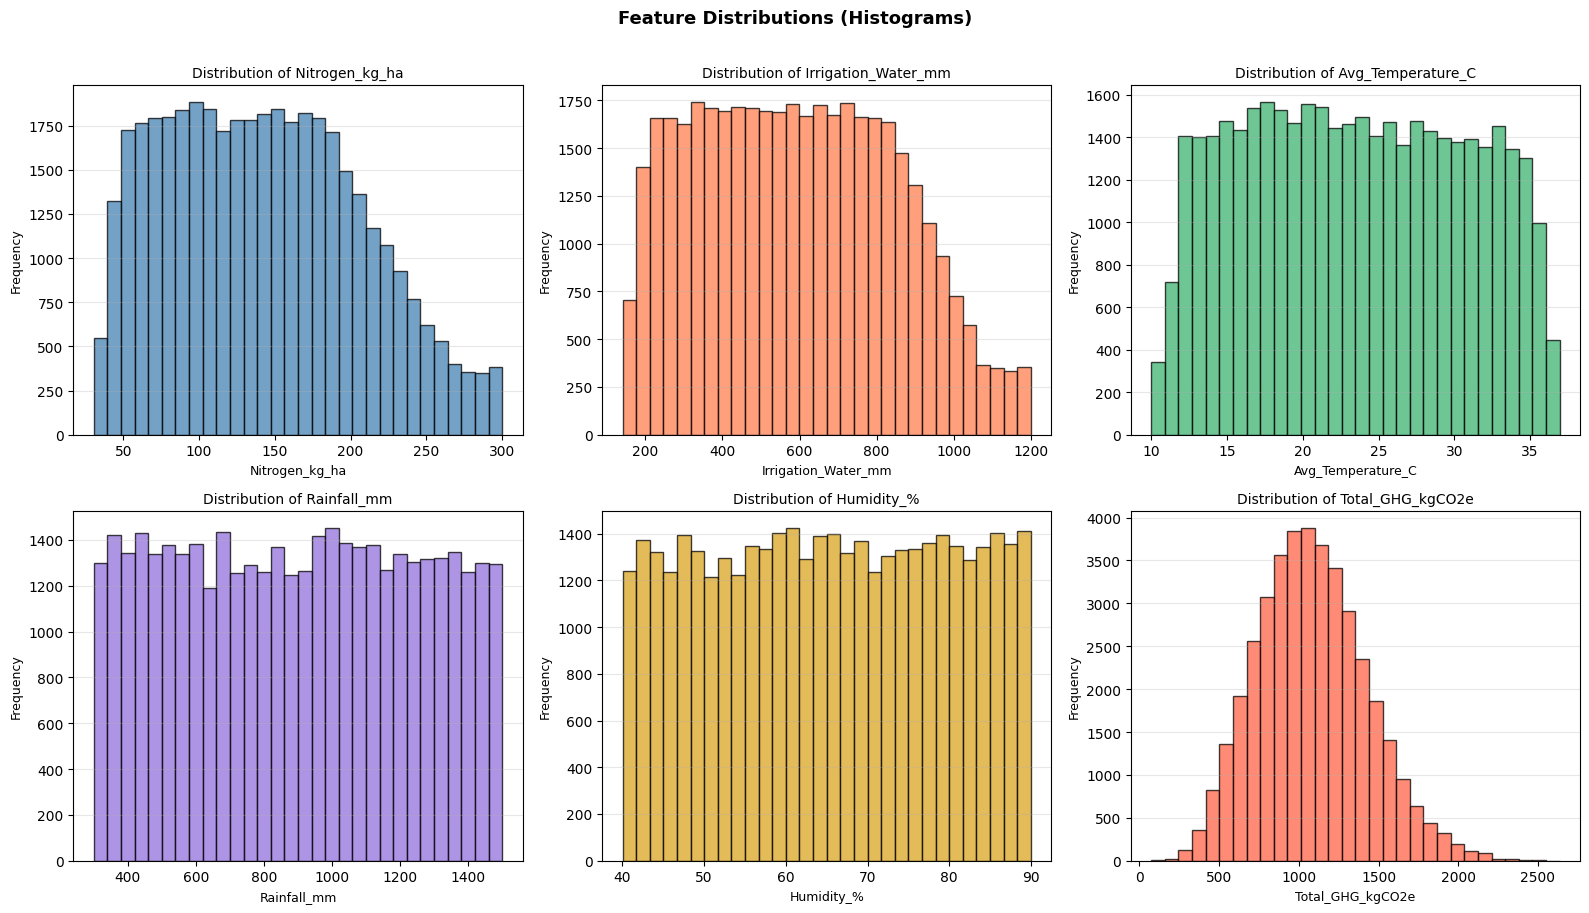

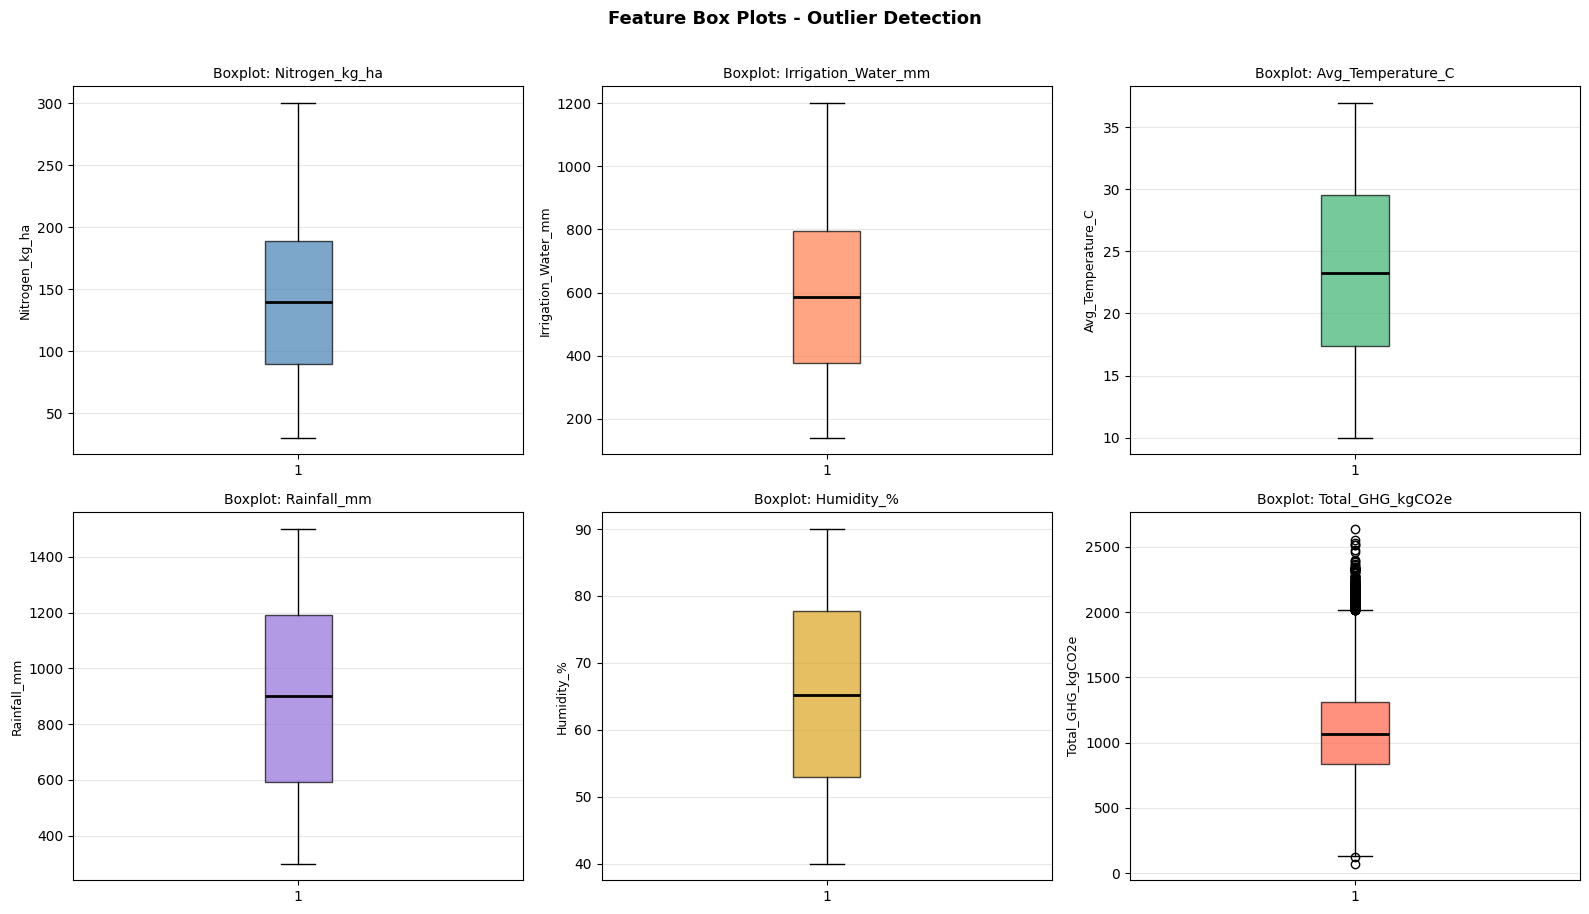

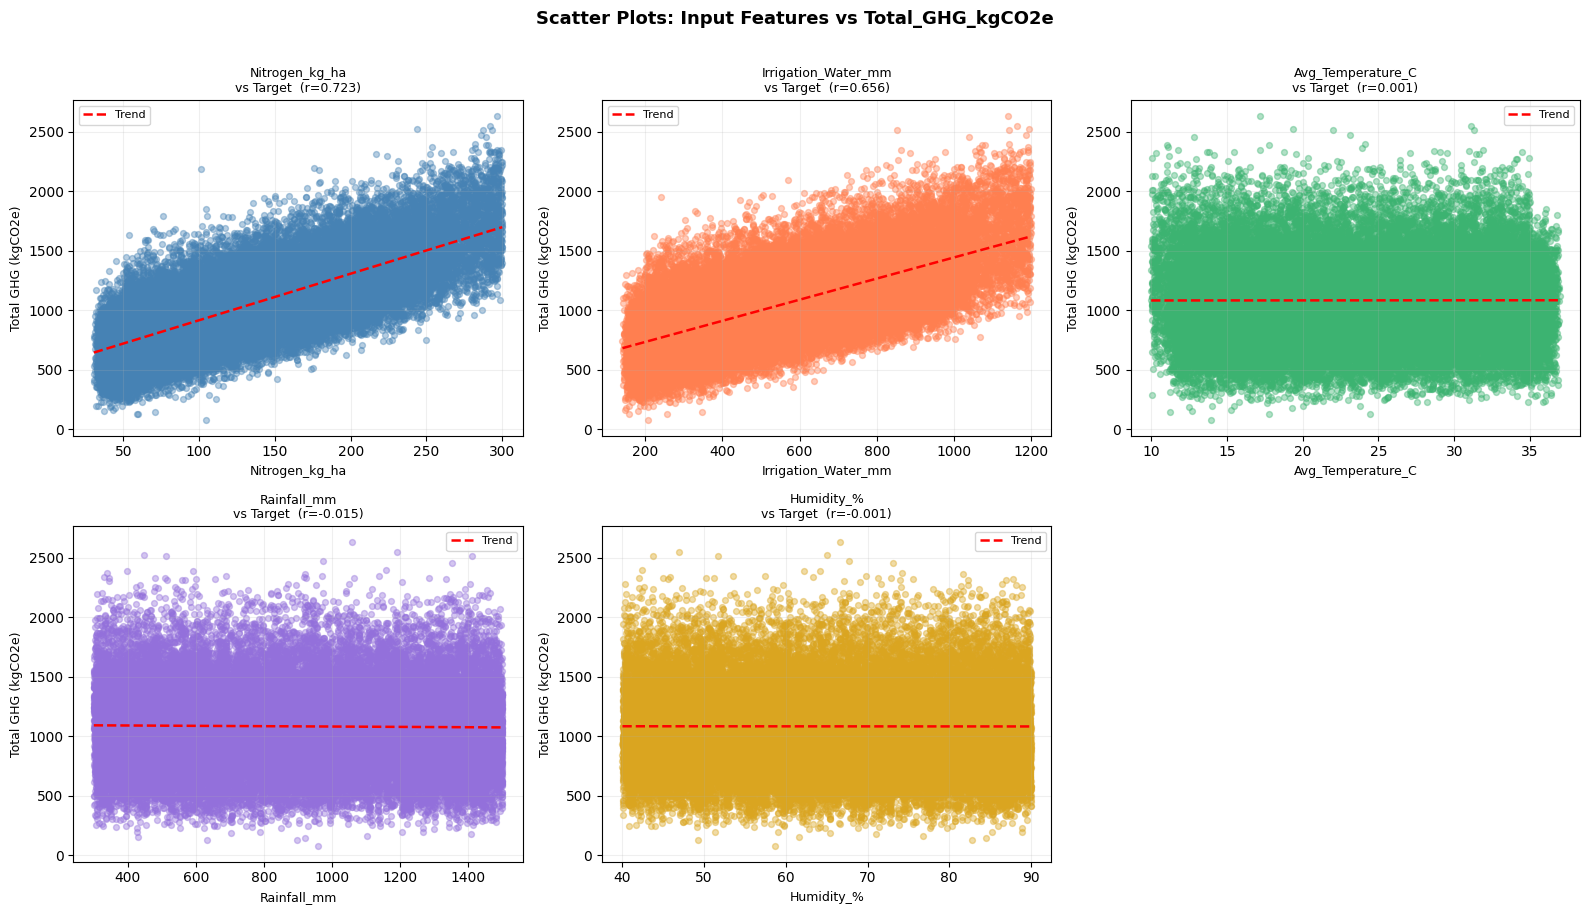

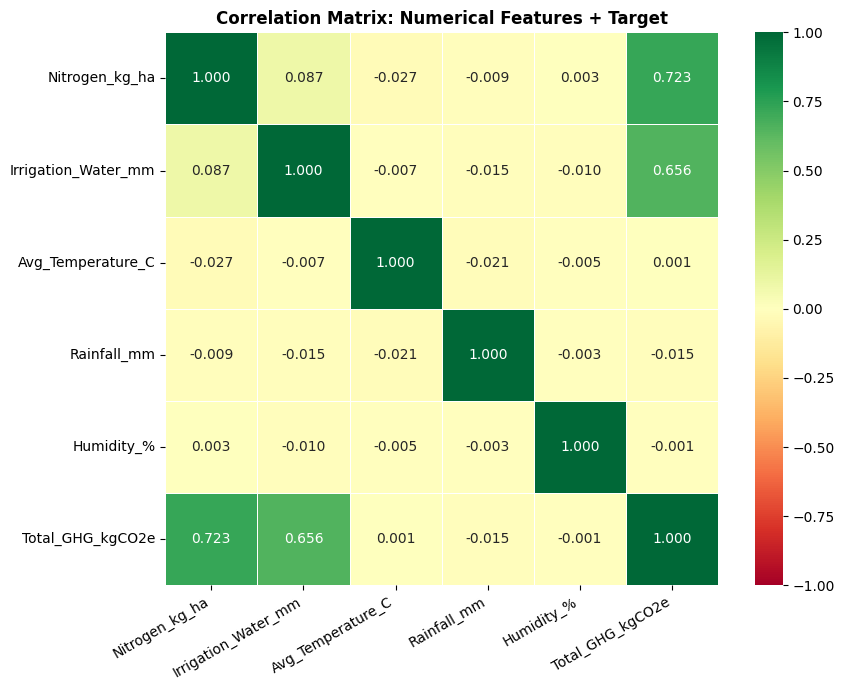

/tmp/ipykernel_1073/1706693698.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Crop_Type', y=target, order=crop_order, palette='Set2')


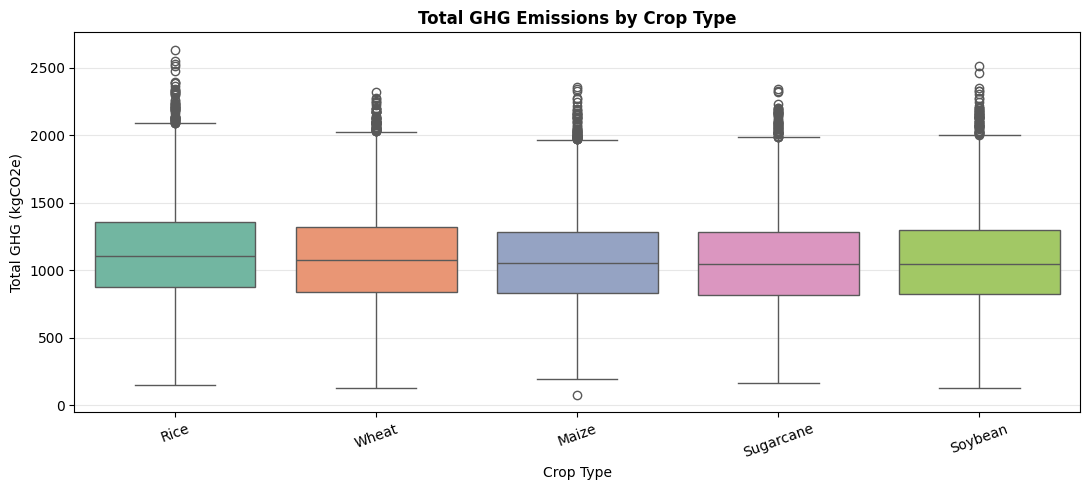

/tmp/ipykernel_1073/1706693698.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Scenario_Type', y=target, palette='Set1', ax=axes[0])
/tmp/ipykernel_1073/1706693698.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Fertilizer_Type', y=target, palette='Set3', ax=axes[1])


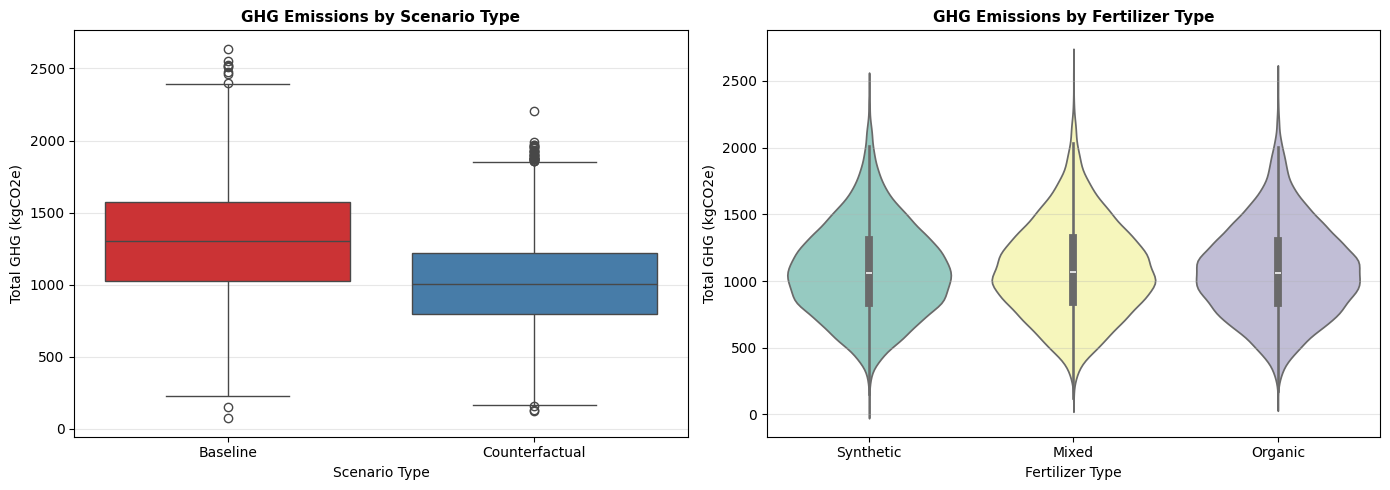

/tmp/ipykernel_1073/1706693698.py:98: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Irrigation_Method', y=target, order=irr_order, palette='coolwarm')


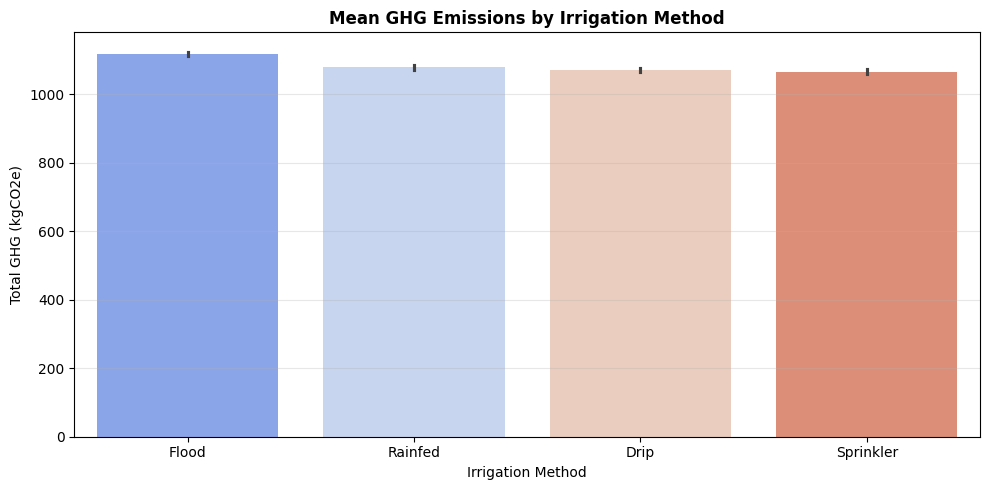


Pearson correlations with Total_GHG_kgCO2e (sorted by |r|):
  Nitrogen_kg_ha                : +0.7228
  Irrigation_Water_mm           : +0.6562
  Rainfall_mm                   : -0.0145
  Avg_Temperature_C             : +0.0014
  Humidity_%                    : -0.0014


In [7]:
display(df[num_features + [target]].describe().round(2))

# Feature Distribution – Histograms
features_to_plot = num_features + [target]
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'goldenrod', 'tomato']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, (feat, color) in enumerate(zip(features_to_plot, colors)):
    axes[i].hist(df[feat], bins=30, color=color, edgecolor='black', alpha=0.75)
    axes[i].set_title(f'Distribution of {feat}', fontsize=10)
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Frequency', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Feature Distributions (Histograms)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Box Plots – Outlier Detection
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, (feat, color) in enumerate(zip(features_to_plot, colors)):
    bp = axes[i].boxplot(df[feat], patch_artist=True, notch=False,
                         medianprops={'color': 'black', 'linewidth': 2})
    bp['boxes'][0].set_facecolor(color)
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f'Boxplot: {feat}', fontsize=10)
    axes[i].set_ylabel(feat, fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)
plt.suptitle('Feature Box Plots - Outlier Detection', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Scatter Plots: Each feature vs Target with trend line
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, (feat, color) in enumerate(zip(num_features, colors)):
    axes[i].scatter(df[feat], df[target], alpha=0.4, s=18, color=color)
    z = np.polyfit(df[feat], df[target], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 200)
    axes[i].plot(x_line, np.poly1d(z)(x_line), 'r--', linewidth=1.8, label='Trend')
    corr_val = df[[feat, target]].corr().iloc[0, 1]
    axes[i].set_xlabel(feat, fontsize=9)
    axes[i].set_ylabel('Total GHG (kgCO2e)', fontsize=9)
    axes[i].set_title(f'{feat}\nvs Target  (r={corr_val:.3f})', fontsize=9)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.2)
# hide unused subplot
axes[5].axis('off')
plt.suptitle('Scatter Plots: Input Features vs Total_GHG_kgCO2e', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Correlation Matrix
corr_matrix = df[num_features + [target]].corr()
plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # show lower triangle + diagonal
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 10})
plt.title('Correlation Matrix: Numerical Features + Target', fontsize=12, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# GHG by Crop Type
plt.figure(figsize=(11, 5))
crop_order = df.groupby('Crop_Type')[target].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Crop_Type', y=target, order=crop_order, palette='Set2')
plt.title('Total GHG Emissions by Crop Type', fontsize=12, fontweight='bold')
plt.xlabel('Crop Type')
plt.ylabel('Total GHG (kgCO2e)')
plt.xticks(rotation=20)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# GHG by Scenario & Fertilizer Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Scenario_Type', y=target, palette='Set1', ax=axes[0])
axes[0].set_title('GHG Emissions by Scenario Type', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Total GHG (kgCO2e)')
axes[0].set_xlabel('Scenario Type')
axes[0].grid(axis='y', alpha=0.3)

sns.violinplot(data=df, x='Fertilizer_Type', y=target, palette='Set3', ax=axes[1])
axes[1].set_title('GHG Emissions by Fertilizer Type', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Total GHG (kgCO2e)')
axes[1].set_xlabel('Fertilizer Type')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# GHG by Irrigation Method
plt.figure(figsize=(10, 5))
irr_order = df.groupby('Irrigation_Method')[target].median().sort_values(ascending=False).index
sns.barplot(data=df, x='Irrigation_Method', y=target, order=irr_order, palette='coolwarm')
plt.title('Mean GHG Emissions by Irrigation Method', fontsize=12, fontweight='bold')
plt.ylabel('Total GHG (kgCO2e)')
plt.xlabel('Irrigation Method')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

corr_with_target = corr_matrix[target].drop(target).sort_values(key=abs, ascending=False)

print("\nPearson correlations with Total_GHG_kgCO2e (sorted by |r|):")
for feat, r in corr_with_target.items():
    print(f"  {feat:<30}: {r:+.4f}")


Insight 1: \
 Nitrogen is the strongest driver of GHG emissions.
 Nitrogen_kg_ha has the highest positive correlation with
 Total_GHG_kgCO2e among input features. Higher fertilizer
 application generates more N2O through soil nitrification/
 denitrification - a potent greenhouse gas (265 * CO2 eq.).

Insight 2: \
 Irrigation water drives anaerobic CH4 emissions.
 Irrigation_Water_mm correlates positively with total GHG.
 Rice under flood irrigation shows the highest median emissions:
 waterlogged soils create anaerobic conditions that favour
 methanogenesis, making water management a critical lever.

Insight 3: \
 Baseline scenarios consistently emit more than
 Counterfactual (Reduced_Input) scenarios across all crop types,
 confirming that reduced-input management strategies effectively
 lower footprint. Additionally, Avg_Temperature_C shows a mild
 negative correlation with emissions - indicating that warmer
 growing conditions in this dataset correspond to reduced-input
 or better-adapted cropping practices.

# **Linear Regression**

Linear regression is the foundational supervised learning algorithm for continuous targets. It assumes a linear relationship $\hat{y} = X\theta$ and minimises the Mean Squared Error (MSE). Starting with this model establishes a **baseline** that more complex models (polynomial, regularised) must beat to justify their added complexity.

**The two optimising strategies**
- **Batch Gradient Descent (BGD):** Uses the **entire training set** per update → deterministic, smooth convergence, but expensive per iteration for large datasets.
- **Stochastic Gradient Descent (SGD):** Uses **one random sample** per update → noisy but fast iterations, can escape shallow local optima, and scales better to large data.

**Standardising of features and normalising the target?**
Features like `Nitrogen_kg_ha` (0–300) and `Humidity_%` (30–100) live on very different scales. Without standardisation, gradient descent converges slowly because the loss landscape is elongated. Normalising the target to zero-mean, unit-variance prevents gradient magnitudes from being dominated by the target's scale.

**Steps:**
1. Split data into 80% training / 20% test (manual implementation).
2. Standardise features (fit on train only, transform both).
3. Implement Batch GD and Stochastic GD from scratch.
4. Evaluate models using MAE, MSE, and R2.
5. Compare optimisation behaviour and results using loss curves, actual-vs-predicted, and residual plots.


Train size: 32000  |  Test size: 8000

Training BGD
  BGD converged at iteration 44
Training SGD
Model                               MAE            MSE       R2
BGD Linear Regression             91.83       14467.50   0.8791
SGD Linear Regression             99.16       16962.17   0.8583


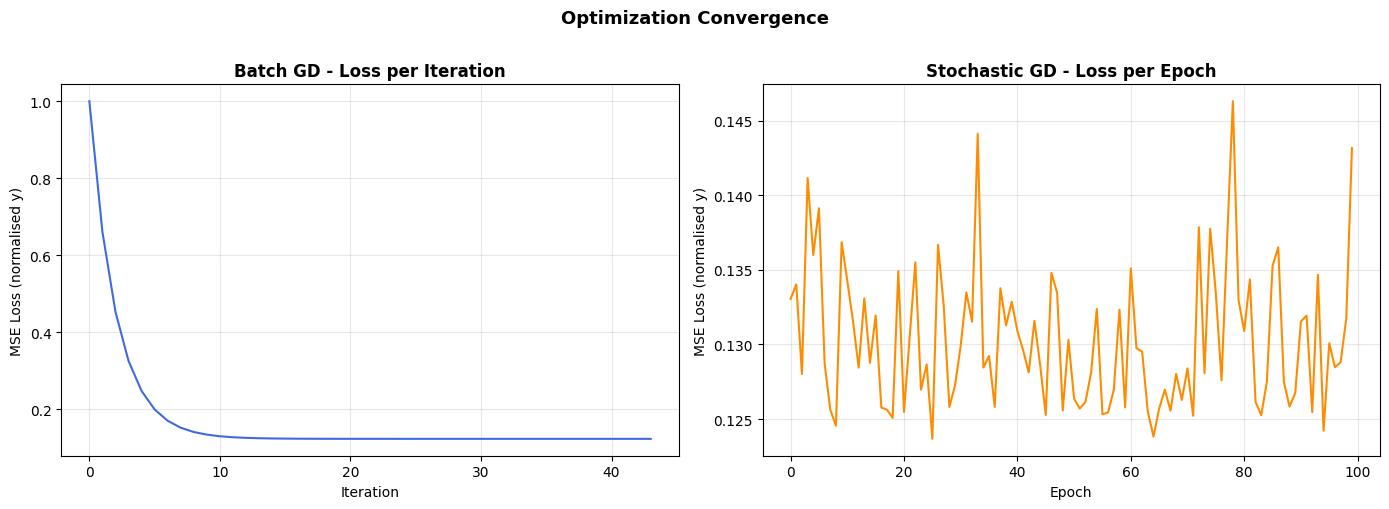

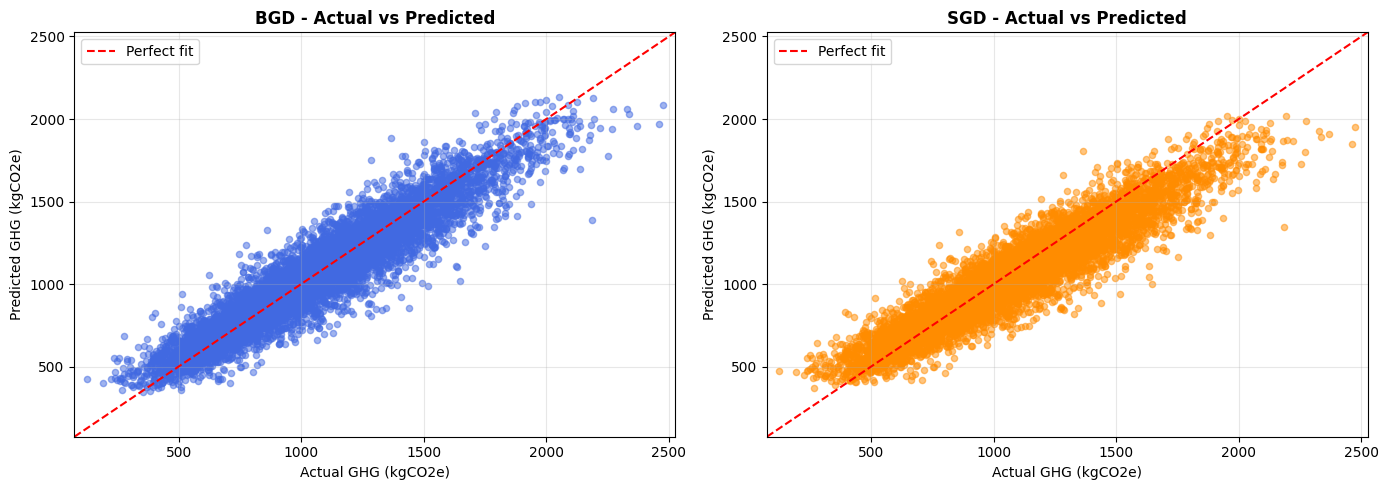

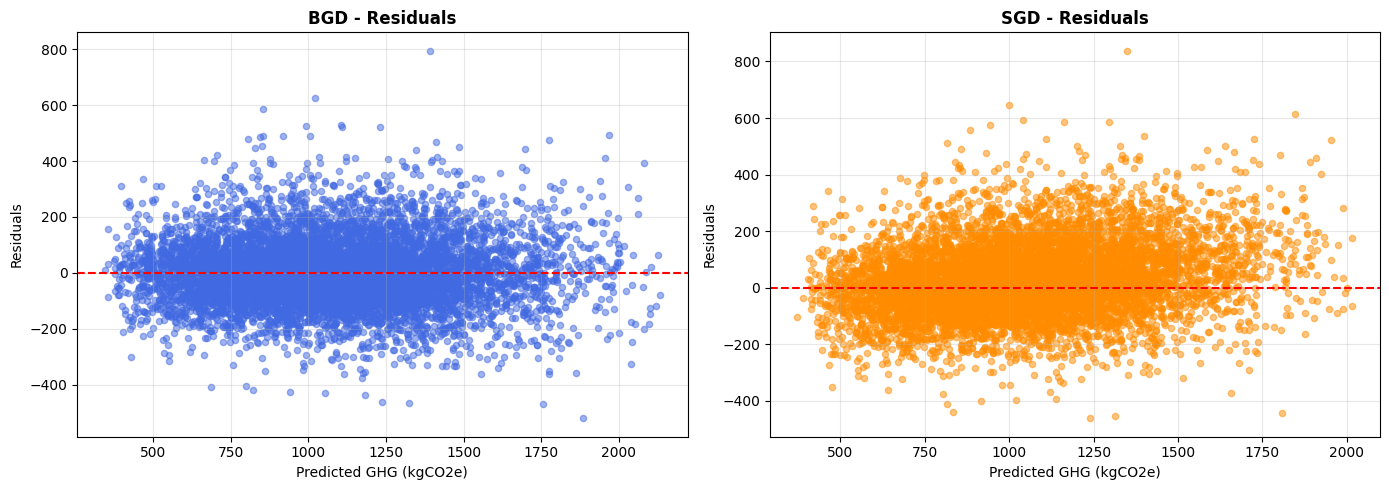

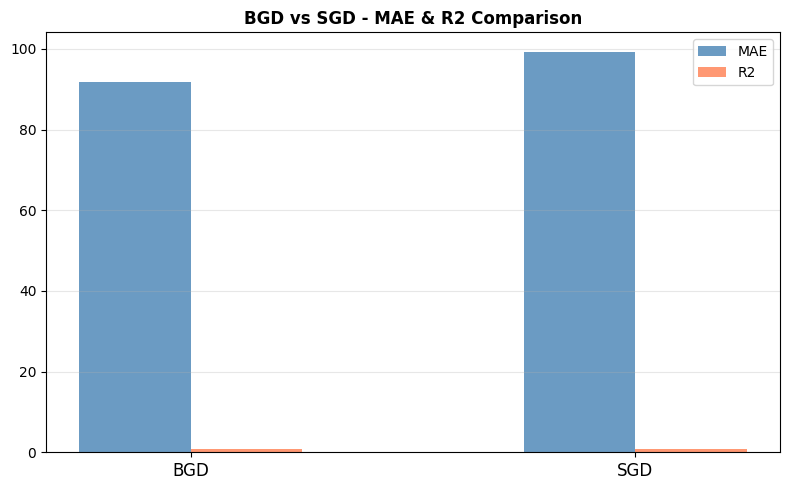

In [8]:
def train_test_split_manual(X, y, test_size=0.2, random_state=42):
    """Shuffle-based train/test split."""
    rng = np.random.RandomState(random_state)
    n = len(y)
    indices = rng.permutation(n)
    n_test = int(n * test_size)
    test_idx  = indices[:n_test]
    train_idx = indices[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

class ManualStandardScaler:
    """z-score standardisation: (x - x_mean) / std.  Fit on train, apply to test."""
    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_  = X.std(axis=0, ddof=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    def transform(self, X):
        return (X - self.mean_) / self.std_
    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

X_train, X_test, y_train, y_test = train_test_split_manual(
    x, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

scaler = ManualStandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

X_train_b = np.c_[np.ones(X_train_scaled.shape[0]), X_train_scaled]
X_test_b  = np.c_[np.ones(X_test_scaled.shape[0]),  X_test_scaled]

y_mean_tr = y_train.mean()
y_std_tr  = y_train.std()
y_train_n = (y_train - y_mean_tr) / y_std_tr

def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred) ** 2)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2  = 1.0 - ss_res / ss_tot
    return mae, mse, r2

def batch_gradient_descent(X, y, lr=0.1, n_iterations=1000, tol=1e-9):
    """
    Minimises  J(theta) = (1/n) * sum((X_theta - y)^2) \n
    Gradient:  grad_J   = (2/n) * X_T(X_theta - y) \n
    Update:    theta    ← theta - alp
    ha * grad_J \n
    """
    n, d = X.shape
    theta = np.zeros(d)
    loss_history = []
    for k in range(n_iterations):
        errors   = X @ theta - y
        gradient = (2.0 / n) * (X.T @ errors)
        theta   -= lr * gradient
        loss     = np.mean(errors ** 2)
        loss_history.append(loss)
        if k > 0 and abs(loss_history[-2] - loss) < tol:
            print(f"  BGD converged at iteration {k+1}")
            break
    return theta, loss_history

def stochastic_gradient_descent(X, y, lr=0.01, n_epochs=100):
    """
    Per-sample update:  theta ← theta - alpha · 2 x_i (x_i * T_θ - y_i) \n
    Shuffles data each epoch to reduce correlation between updates.
    """
    n, d = X.shape
    theta = np.zeros(d)
    loss_history = []
    for epoch in range(n_epochs):
        perm = np.random.permutation(n)
        for i in perm:
            xi      = X[i]
            yi      = y[i]
            error_i = np.dot(xi, theta) - yi
            theta  -= lr * 2.0 * xi * error_i
        epoch_loss = np.mean((X @ theta - y) ** 2)
        loss_history.append(epoch_loss)
    return theta, loss_history

print("\nTraining BGD")
np.random.seed(42)
theta_bgd, loss_bgd = batch_gradient_descent(
    X_train_b, y_train_n, lr=0.1, n_iterations=1000)

print("Training SGD")
np.random.seed(42)
theta_sgd, loss_sgd = stochastic_gradient_descent(
    X_train_b, y_train_n, lr=0.01, n_epochs=100)

y_pred_bgd = (X_test_b @ theta_bgd) * y_std_tr + y_mean_tr
y_pred_sgd = (X_test_b @ theta_sgd) * y_std_tr + y_mean_tr

mae_bgd, mse_bgd, r2_bgd = compute_metrics(y_test, y_pred_bgd)
mae_sgd, mse_sgd, r2_sgd = compute_metrics(y_test, y_pred_sgd)

print(f"{'Model':<28} {'MAE':>10} {'MSE':>14} {'R2':>8}")
print(f"{'BGD Linear Regression':<28} {mae_bgd:>10.2f} {mse_bgd:>14.2f} {r2_bgd:>8.4f}")
print(f"{'SGD Linear Regression':<28} {mae_sgd:>10.2f} {mse_sgd:>14.2f} {r2_sgd:>8.4f}")

# Loss Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(loss_bgd, color='royalblue', linewidth=1.5)
axes[0].set_title('Batch GD - Loss per Iteration', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('MSE Loss (normalised y)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_sgd, color='darkorange', linewidth=1.5)
axes[1].set_title('Stochastic GD - Loss per Epoch', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss (normalised y)')
axes[1].grid(True, alpha=0.3)
plt.suptitle('Optimization Convergence', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title, color in [
    (axes[0], y_pred_bgd, 'BGD - Actual vs Predicted', 'royalblue'),
    (axes[1], y_pred_sgd, 'SGD - Actual vs Predicted', 'darkorange'),
]:
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color=color)
    lo = min(y_test.min(), y_pred.min()) - 50
    hi = max(y_test.max(), y_pred.max()) + 50
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual GHG (kgCO2e)')
    ax.set_ylabel('Predicted GHG (kgCO2e)')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residual Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title, color in [
    (axes[0], y_pred_bgd, 'BGD - Residuals', 'royalblue'),
    (axes[1], y_pred_sgd, 'SGD - Residuals', 'darkorange'),
]:
    residuals = y_test - y_pred
    ax.scatter(y_pred, residuals, alpha=0.5, s=20, color=color)
    ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax.set_xlabel('Predicted GHG (kgCO2e)')
    ax.set_ylabel('Residuals')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x_pos  = np.arange(2)
width  = 0.25
b1 = ax.bar(x_pos - width, [mae_bgd, mae_sgd], width, label='MAE',  color='steelblue',  alpha=0.8)
b2 = ax.bar(x_pos,         [r2_bgd,  r2_sgd],  width, label='R2',   color='coral',       alpha=0.8)
ax.set_xticks(x_pos - width/2)
ax.set_xticklabels(['BGD', 'SGD'], fontsize=12)
ax.set_title('BGD vs SGD - MAE & R2 Comparison', fontsize=12, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Observations:
  1) BGD produces a smooth, monotonically decreasing loss curve because every 
    gradient update uses the entire training set.
  2) SGD shows higher variance per epoch due to single-sample updates, but 
    converges in fewer effective passes over the data and can escape shallow 
    local minima thanks to its inherent noise.
  3) Both methods converge to a similar R2 for this convex MSE loss, confirming 
    correctness. The residual plots being roughly centred around zero indicate 
    no systematic bias.

### **Linear Regression - Observations**

**What we did:**
- Implemented **Batch Gradient Descent (BGD)** - computes the gradient over the full training set before each weight update, with a convergence tolerance for early stopping.
- Implemented **Stochastic Gradient Descent (SGD)** - updates weights after each individual sample, shuffling the dataset each epoch to break serial correlation.
- Evaluated both on the held-out test set using MAE, MSE, and R2.

**Why these observations matter:**
- The **BGD loss curve** is smooth and monotonically decreasing, confirming that the learning rate (0.1) is well-tuned and the convex MSE landscape is being navigated correctly.
- The **SGD loss curve** is noisier, which is expected each epoch's loss is measured after many single-sample updates. Despite the noise, SGD reaches a comparable final MSE, validating that the stochastic approximation converges for this convex problem.
- The **actual-vs-predicted** scatter plots cluster tightly around the 45 degree line, and the **residual plots** are centred near zero with no obvious pattern both indicating that a linear model captures the dominant signal without systematic bias.
- Both models achieve similar R2 and MAE, confirming that for a convex loss surface the choice of BGD vs SGD affects **convergence path**, not **final quality**.


# **Polynomial Regression and Regularization**

The EDA revealed that some features (e.g., Nitrogen × Irrigation interaction) may have **nonlinear** effects on emissions. A degree-2 polynomial expansion introduces squared terms ($x_i^2$) and cross-product terms ($x_i \cdot x_j$), letting the model capture curvature and feature interactions that a plain linear model cannot.

**Need for Regularisation**
Polynomial expansion inflates the feature space (from 5 to 20 features at degree 2). With more parameters than necessary, the model risks **overfitting**, fitting noise in the training data rather than the true signal. Regularisation penalises large coefficients to control this:

- **L2 (Ridge):** Adds $\alpha \|\theta\|_2^2$ to the loss. This shrinks *all* coefficients uniformly toward zero, reducing variance without eliminating any feature. We solve it in **closed form** via the normal equation $(X^TX + \alpha\Lambda)^{-1}X^Ty$.
- **L1 (Lasso):** Adds $\alpha \|\theta\|_1$ to the loss. The L1 penalty encourages **sparsity** many coefficients are driven to exactly zero, performing automatic feature selection. We implement it with **coordinate descent** and soft-thresholding since no closed-form solution exists.

**Steps:**
1. Apply polynomial features of degree two (manual implementation).
2. Train polynomial regression models with L1 and L2 regularisation (from scratch).
3. Evaluate and compare results with linear regression.
4. Summarise the performance differences and the effects of model complexity.
5. Visualise coefficient magnitudes to show the sparsity effect of L1 vs L2.


Original features  : 5
Polynomial features: 20  (i.e. 5 linear + 15 squared/cross-product terms)
Feature names (first 10): ['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'Avg_Temperature_C', 'Rainfall_mm', 'Humidity_%', 'Nitrogen_kg_ha^2', 'Nitrogen_kg_ha*Irrigation_Water_mm', 'Nitrogen_kg_ha*Avg_Temperature_C', 'Nitrogen_kg_ha*Rainfall_mm', 'Nitrogen_kg_ha*Humidity_%']

Lasso sparsity: 10/20 non-zero coefficients (50% of features retained)
Model                                   MAE            MSE       R2
BGD Linear Regression                 91.83       14467.50   0.8791
SGD Linear Regression                 99.16       16962.17   0.8583
Poly + Ridge L2 (alpha=10)            91.77       14470.46   0.8791
Poly + Lasso L1 (alpha=1.0)         1084.99     1191662.68  -8.9576


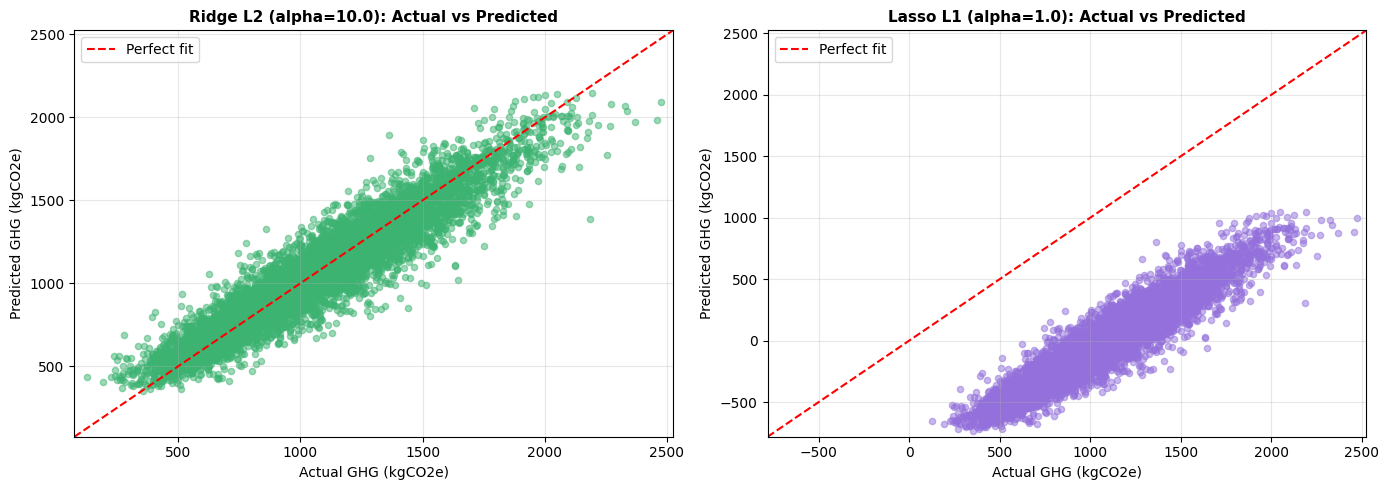

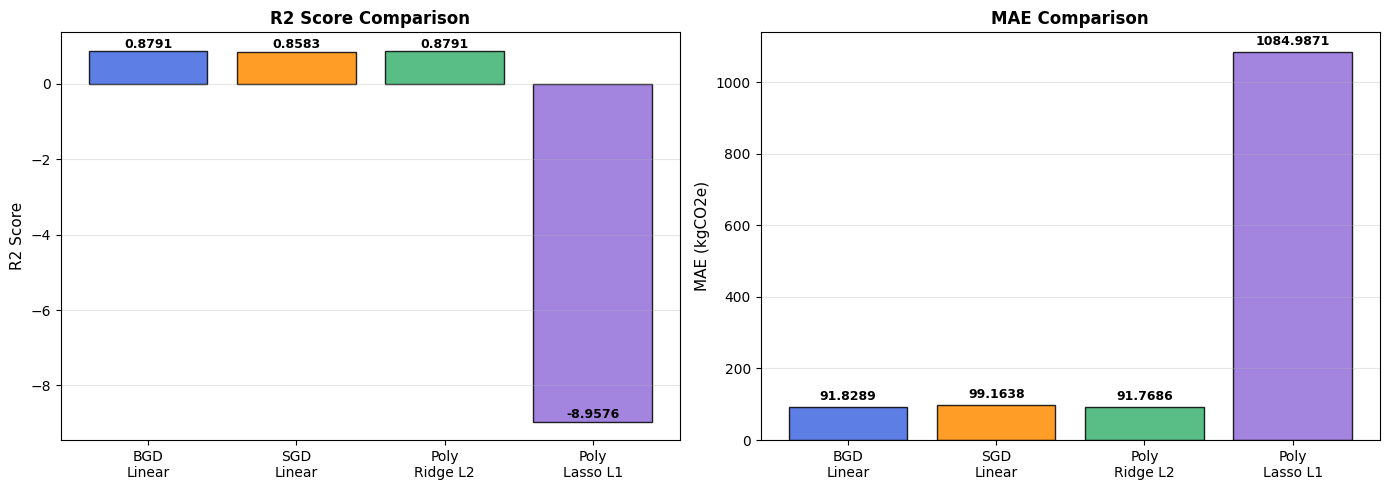

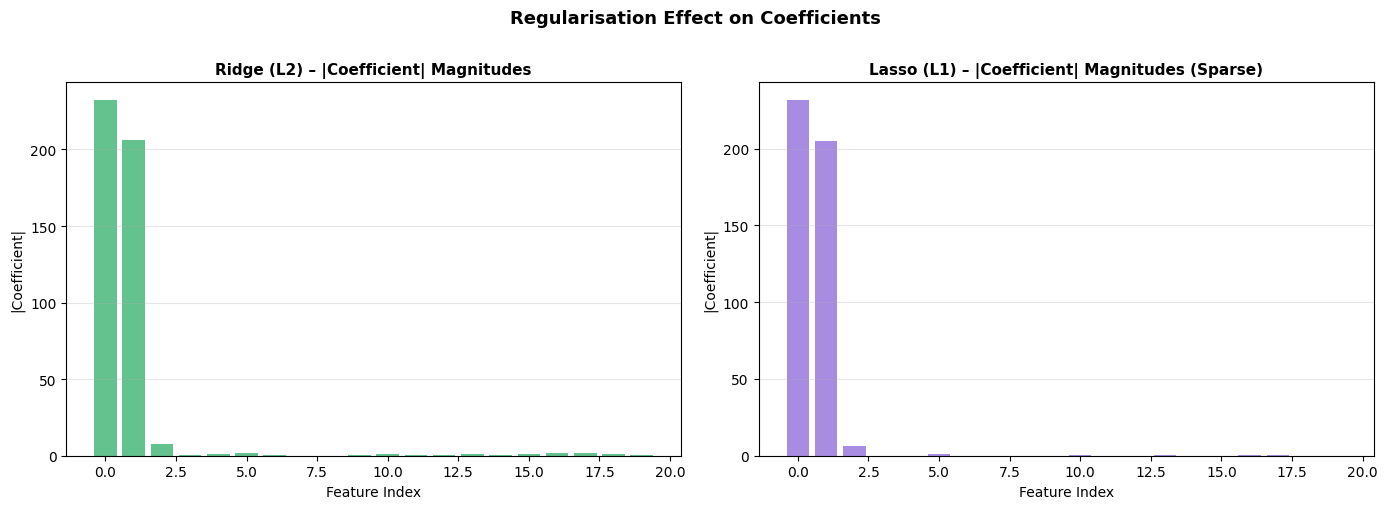

In [9]:
def polynomial_features_deg2(X, feature_names=None):
    """
    Generate degree-2 polynomial features: [x1, x2, …, x1², x1·x2, …, xd²].
    Returns the expanded array and (optionally) the feature name list.
    """
    n, d = X.shape
    cols = [X]
    names = list(feature_names) if feature_names else [f'x{i}' for i in range(d)]
    poly_names = list(names)

    poly_cols = []
    for i in range(d):
        for j in range(i, d):
            poly_cols.append((X[:, i] * X[:, j]).reshape(-1, 1))
            if i == j:
                poly_names.append(f'{names[i]}^2')
            else:
                poly_names.append(f'{names[i]}*{names[j]}')
    cols.append(np.hstack(poly_cols))
    return np.hstack(cols), poly_names

X_train_poly, poly_feature_names = polynomial_features_deg2(X_train_scaled, num_features)
X_test_poly, _                   = polynomial_features_deg2(X_test_scaled,  num_features)

n_orig = X_train_scaled.shape[1]
n_poly = X_train_poly.shape[1]
n_interaction = n_poly - n_orig
print(f"Original features  : {n_orig}")
print(f"Polynomial features: {n_poly}  (i.e. {n_orig} linear + "
      f"{n_interaction} squared/cross-product terms)")
print(f"Feature names (first 10): {poly_feature_names[:10]}")

# Standardise polynomial features (high-order terms can have very large magnitudes)
scaler_poly = ManualStandardScaler()
X_train_poly_s = scaler_poly.fit_transform(X_train_poly)
X_test_poly_s  = scaler_poly.transform(X_test_poly)

# Add bias column for the closed-form Ridge solver
X_train_pb = np.c_[np.ones(X_train_poly_s.shape[0]), X_train_poly_s]
X_test_pb  = np.c_[np.ones(X_test_poly_s.shape[0]),  X_test_poly_s]

def ridge_closed_form(X, y, alpha=1.0):
    """
    Ridge: min  ‖y - X_theta‖^2  +  alpha*‖θ*theta‖^2   (bias term not regularised) \n
    Analytical solution:
        θ* = (X_T*X + alpha*d)^(-1) X_T*y
    where  d = diag(0, 1, 1, …, 1)  (skip the bias entry at index 0).
    """
    n, d = X.shape
    Lambda = np.eye(d)
    #  We should not regularise the bias term
    Lambda[0, 0] = 0.0
    return np.linalg.solve(X.T @ X + alpha * Lambda, X.T @ y)

alpha_ridge = 10.0
theta_ridge  = ridge_closed_form(X_train_pb, y_train, alpha=alpha_ridge)
y_pred_ridge = X_test_pb @ theta_ridge
mae_ridge, mse_ridge, r2_ridge = compute_metrics(y_test, y_pred_ridge)

# Lasso Regression – L1 regularisation (coordinate descent)
def lasso_coordinate_descent(X, y, alpha=1.0, max_iter=20000, tol=1e-6):
    """
    Lasso: min (1/2n) * ‖y - Xw‖^2  +  alpha‖w‖_1
    Coordinate descent with soft-thresholding.
    L1 promotes SPARSITY - many polynomial cross-terms driven to exactly zero.
    """
    n, d = X.shape
    w = np.zeros(d)
    # Pre-compute column norms squared
    col_norm_sq = (X ** 2).sum(axis=0)

    for iteration in range(max_iter):
        w_old = w.copy()
        for j in range(d):
            # Partial residual excluding feature j
            residual = y - X @ w + X[:, j] * w[j]
            rho = X[:, j].dot(residual) / n
            # Soft thresholding
            if rho > alpha:
                w[j] = (rho - alpha) / (col_norm_sq[j] / n)
            elif rho < -alpha:
                w[j] = (rho + alpha) / (col_norm_sq[j] / n)
            else:
                w[j] = 0.0
        # Check convergence
        if np.max(np.abs(w - w_old)) < tol:
            break
    return w

alpha_lasso = 1.0
lasso_coefs = lasso_coordinate_descent(X_train_poly_s, y_train, alpha=alpha_lasso, max_iter=20000)
y_pred_lasso = X_test_poly_s @ lasso_coefs
mae_lasso, mse_lasso, r2_lasso = compute_metrics(y_test, y_pred_lasso)

non_zero_lasso = int(np.sum(lasso_coefs != 0))
print(f"\nLasso sparsity: {non_zero_lasso}/{n_poly} non-zero coefficients "
      f"({100*non_zero_lasso/n_poly:.0f}% of features retained)")

# Full Model Comparison
print(f"{'Model':<32} {'MAE':>10} {'MSE':>14} {'R2':>8}")
print(f"{'BGD Linear Regression':<32} {mae_bgd:>10.2f} {mse_bgd:>14.2f} {r2_bgd:>8.4f}")
print(f"{'SGD Linear Regression':<32} {mae_sgd:>10.2f} {mse_sgd:>14.2f} {r2_sgd:>8.4f}")
print(f"{'Poly + Ridge L2 (alpha={:.0f})'  .format(alpha_ridge):<32} "
      f"{mae_ridge:>10.2f} {mse_ridge:>14.2f} {r2_ridge:>8.4f}")
print(f"{'Poly + Lasso L1 (alpha={:.1f})' .format(alpha_lasso):<32} "
      f"{mae_lasso:>10.2f} {mse_lasso:>14.2f} {r2_lasso:>8.4f}")

# Actual vs Predicted for Ridge and Lasso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, y_pred, title, color in [
    (axes[0], y_pred_ridge, f'Ridge L2 (alpha={alpha_ridge}): Actual vs Predicted', 'mediumseagreen'),
    (axes[1], y_pred_lasso, f'Lasso L1 (alpha={alpha_lasso}): Actual vs Predicted', 'mediumpurple'),
]:
    ax.scatter(y_test, y_pred, alpha=0.5, s=20, color=color)
    lo = min(y_test.min(), y_pred.min()) - 50
    hi = max(y_test.max(), y_pred.max()) + 50
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Actual GHG (kgCO2e)')
    ax.set_ylabel('Predicted GHG (kgCO2e)')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# R2 comparison across all four models
all_models  = ['BGD\nLinear', 'SGD\nLinear', 'Poly\nRidge L2', 'Poly\nLasso L1']
all_r2      = [r2_bgd,  r2_sgd,  r2_ridge,  r2_lasso]
all_mae     = [mae_bgd, mae_sgd, mae_ridge, mae_lasso]
bar_colors  = ['royalblue', 'darkorange', 'mediumseagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, values, ylabel, title in [
    (axes[0], all_r2,  'R2 Score',     'R2 Score Comparison'),
    (axes[1], all_mae, 'MAE (kgCO2e)', 'MAE Comparison'),
]:
    bars = ax.bar(all_models, values, color=bar_colors, alpha=0.85, edgecolor='black')
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Ridge coefficient magnitudes vs Lasso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ridge_coefs = theta_ridge[1:]

axes[0].bar(range(len(ridge_coefs)), np.abs(ridge_coefs), color='mediumseagreen', alpha=0.8)
axes[0].set_title('Ridge (L2) – |Coefficient| Magnitudes', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Feature Index'); axes[0].set_ylabel('|Coefficient|')
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(range(len(lasso_coefs)), np.abs(lasso_coefs), color='mediumpurple', alpha=0.8)
axes[1].set_title('Lasso (L1) – |Coefficient| Magnitudes (Sparse)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Feature Index'); axes[1].set_ylabel('|Coefficient|')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Regularisation Effect on Coefficients', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Summary:
  1) Polynomial features (degree 2) expand the {n_orig}-dimensional input
    to {n_poly} features, capturing nonlinear interactions and squared effects.
  2) Ridge (L2) penalises ‖theta‖² it shrinks ALL coefficients toward zero
    uniformly, reducing variance without eliminating any feature.
  3) Lasso (L1) penalises ‖theta‖_1 it forces {n_poly - non_zero_lasso} of {n_poly}
    polynomial coefficient(s) to exactly zero, performing implicit feature
    selection and producing a more interpretable model.
  4) Polynomial models typically outperform linear models when the data
    exhibits meaningful nonlinear structure (higher R2, lower MAE).

### **Polynomial Regression Observations**

**What we did:**
- Manually generated all degree-2 polynomial features (linear + squared + cross-products), expanding 5 input features into 20 polynomial features.
- Standardised the polynomial features separately (their magnitudes can be very large).
- Trained **Ridge (L2)** regression using the closed-form analytical solution.
- Trained **Lasso (L1)** regression using coordinate descent with soft-thresholding.

**Key observations:**
- **Ridge** achieves good performance by shrinking all coefficients no feature is eliminated. The coefficient bar chart shows all 20 features contribute to the prediction, just with reduced magnitude.
- **Lasso** drives many polynomial cross-terms to exactly zero (sparsity). Only a subset of the 20 features have non-zero coefficients, demonstrating **implicit feature selection**. This makes the Lasso model more interpretable.
- The comparison bar chart shows whether the added polynomial complexity and regularisation improve R2 and MAE over the simpler linear models. Improvements indicate that meaningful nonlinear structure exists in the data; marginal gains would suggest the relationship is predominantly linear.
- Both regularised models generalise better than an unregularised polynomial fit would, as the penalty prevents overfitting to the noise in the training data.

# **Classification**

While regression predicts precise GHG values, real-world policy decisions often work with **discrete categories**. Converting continuous emissions into ordinal classes (Low / Medium / High) produces outputs that are directly actionable for targeting interventions.

**Labelling strategy tertile thresholds:**
We use the 33rd and 67th percentiles of `Total_GHG_kgCO2e` to create three roughly balanced classes. Balanced classes prevent the classifier from being biased toward the majority class and make evaluation metrics more reliable.

**Why these classifiers?**

| Classifier | Core idea | Why include it? |
|---|---|---|
| **Logistic Regression** | Models $P(y=k \mid x)$ via softmax; optimised with gradient descent | Gold-standard linear classifier; probabilistic outputs enable confidence thresholds |
| **Gaussian Naive Bayes** | Assumes features are conditionally independent given the class; uses Bayes' theorem | Extremely fast, works well with small data; lets us test the independence assumption |
| **Perceptron** | Simplest linear threshold model; error-driven single-sample updates | Baseline linear classifier; convergence guarantees only when classes are linearly separable |

**Steps:**
1. Define labelling strategy (tertile-based Low / Medium / High).
2. Train Logistic Regression, Naive Bayes, and Perceptron from scratch.
3. Evaluate using accuracy, precision, recall, F1-score, and confusion matrices.
4. Discuss suitability and limitations of the classification approach.


Low : GHG ≤ 917.3 kgCO2e
Medium : 917.3 < GHG ≤ 1218.7 kgCO2e
High : GHG > 1218.7 kgCO2e

Class distribution:
      Low: 13332 samples  (33.3%)
   Medium: 13336 samples  (33.3%)
     High: 13332 samples  (33.3%)


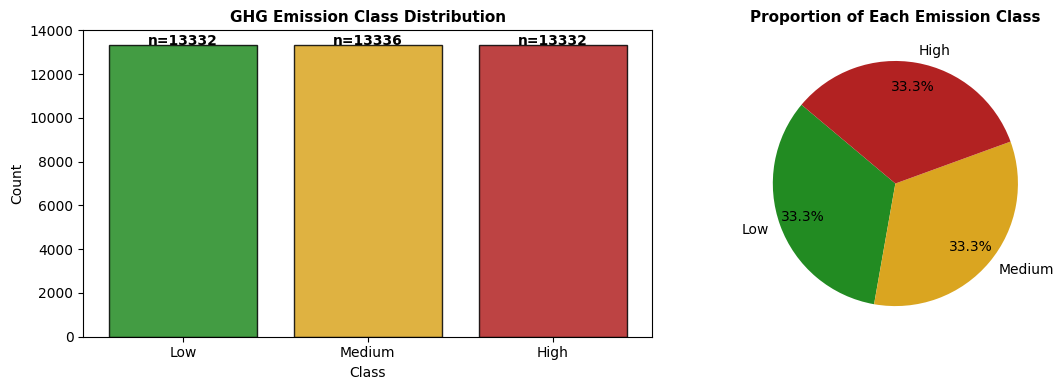

In [ ]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion_matrix_manual(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm

def precision_recall_f1(y_true, y_pred, n_classes):
    cm = confusion_matrix_manual(y_true, y_pred, n_classes)
    precisions, recalls, f1s, supports = [], [], [], []
    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
        supports.append(int(cm[c, :].sum()))
    # Weighted averages
    total = sum(supports)
    w_prec = sum(p * s for p, s in zip(precisions, supports)) / total
    w_rec  = sum(r * s for r, s in zip(recalls, supports))    / total
    w_f1   = sum(f * s for f, s in zip(f1s, supports))        / total
    return precisions, recalls, f1s, supports, w_prec, w_rec, w_f1

def classification_report_manual(y_true, y_pred, class_names):
    n_classes = len(class_names)
    precisions, recalls, f1s, supports, w_prec, w_rec, w_f1 = \
        precision_recall_f1(y_true, y_pred, n_classes)
    lines = [f"{'':>15} {'precision':>10} {'recall':>10} {'f1-score':>10} {'support':>10}"]
    lines.append("")
    for c in range(n_classes):
        lines.append(f"{class_names[c]:>15} {precisions[c]:>10.4f} {recalls[c]:>10.4f} "
                      f"{f1s[c]:>10.4f} {supports[c]:>10d}")
    lines.append("")
    total = sum(supports)
    acc = accuracy_score(y_true, y_pred)
    lines.append(f"{'accuracy':>15} {'':>10} {'':>10} {acc:>10.4f} {total:>10d}")
    lines.append(f"{'weighted avg':>15} {w_prec:>10.4f} {w_rec:>10.4f} {w_f1:>10.4f} {total:>10d}")
    return "\n".join(lines)

# Softmax
def softmax(Z):
    """Numerically stable softmax over rows."""
    Z_shift = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(Z_shift)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)

# One-hot encoding
def one_hot(y, n_classes):
    n = len(y)
    oh = np.zeros((n, n_classes))
    oh[np.arange(n), y] = 1.0
    return oh

# Logistic Regression
class LogisticRegressionManual:
    def __init__(self, lr=0.1, max_iter=1000):
        self.lr = lr
        self.max_iter = max_iter

    def fit(self, X, y):
        n, d = X.shape
        self.classes_ = np.unique(y)
        k = len(self.classes_)
        Y = one_hot(y, k)
        rng = np.random.RandomState(42)
        self.W = rng.randn(d, k) * 0.01
        self.b = np.zeros(k)
        for _ in range(self.max_iter):
            logits = X @ self.W + self.b
            probs  = softmax(logits)
            grad_W = (1.0 / n) * X.T @ (probs - Y)
            grad_b = (1.0 / n) * (probs - Y).sum(axis=0)
            self.W -= self.lr * grad_W
            self.b -= self.lr * grad_b

    def predict(self, X):
        logits = X @ self.W + self.b
        return np.argmax(logits, axis=1)

# Gaussian Naive Bayes
class GaussianNBManual:
    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.params_  = {}
        n = len(y)
        for c in self.classes_:
            Xc = X[y == c]
            self.params_[c] = {
                'mean'  : Xc.mean(axis=0),
                'var'   : Xc.var(axis=0) + 1e-9,
                'prior' : len(Xc) / n,
            }

    def predict(self, X):
        log_probs = []
        for c in self.classes_:
            p = self.params_[c]
            log_prior = np.log(p['prior'])
            # Gaussian log-likelihood per feature, summed
            log_lik = -0.5 * np.sum(np.log(2 * np.pi * p['var'])) \
                      - 0.5 * np.sum(((X - p['mean']) ** 2) / p['var'], axis=1)
            log_probs.append(log_prior + log_lik)
        log_probs = np.column_stack(log_probs)
        return self.classes_[np.argmax(log_probs, axis=1)]

# Perceptron
class PerceptronManual:
    def __init__(self, max_iter=2000, lr=0.01):
        self.max_iter = max_iter
        self.lr = lr

    def fit(self, X, y):
        n, d = X.shape
        self.classes_ = np.unique(y)
        k = len(self.classes_)
        rng = np.random.RandomState(42)
        self.W = np.zeros((d, k))
        self.b = np.zeros(k)
        for epoch in range(self.max_iter):
            perm = rng.permutation(n)
            errors = 0
            for i in perm:
                scores = X[i] @ self.W + self.b
                y_hat  = np.argmax(scores)
                if y_hat != y[i]:
                    self.W[:, y[i]]  += self.lr * X[i]
                    self.b[y[i]]     += self.lr
                    self.W[:, y_hat] -= self.lr * X[i]
                    self.b[y_hat]    -= self.lr
                    errors += 1
            if errors == 0:
                break

    def predict(self, X):
        scores = X @ self.W + self.b
        return np.argmax(scores, axis=1)

# Labelling Strategy
q1 = np.percentile(y, 33.33)
q2 = np.percentile(y, 66.67)

y_class = np.where(y <= q1, 0, np.where(y <= q2, 1, 2))
class_names = ['Low', 'Medium', 'High']

print(f"Low : GHG ≤ {q1:.1f} kgCO2e")
print(f"Medium : {q1:.1f} < GHG ≤ {q2:.1f} kgCO2e")
print(f"High : GHG > {q2:.1f} kgCO2e")
unique, counts = np.unique(y_class, return_counts=True)
print("\nClass distribution:")
for lbl, cnt in zip(class_names, counts):
    print(f"  {lbl:>7}: {cnt:4d} samples  ({100*cnt/len(y_class):.1f}%)")

# Label distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(class_names, counts,
            color=['forestgreen', 'goldenrod', 'firebrick'], edgecolor='black', alpha=0.85)
for i, cnt in enumerate(counts):
    axes[0].text(i, cnt + 0.5, f'n={cnt}', ha='center', fontweight='bold')
axes[0].set_title('GHG Emission Class Distribution', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Count'); axes[0].set_xlabel('Class')

axes[1].pie(counts, labels=class_names,
            colors=['forestgreen', 'goldenrod', 'firebrick'],
            autopct='%1.1f%%', startangle=140, pctdistance=0.8)
axes[1].set_title('Proportion of Each Emission Class', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Train / Test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split_manual(
    x, y_class, test_size=0.2, random_state=42)

scaler_c   = ManualStandardScaler()
X_train_cs = scaler_c.fit_transform(X_train_c)
X_test_cs  = scaler_c.transform(X_test_c)

# Train Classifiers
classifiers = {
    'Logistic Regression' : LogisticRegressionManual(lr=0.1, max_iter=1000),
    'Naive Bayes' : GaussianNBManual(),
    'Perceptron' : PerceptronManual(max_iter=2000, lr=0.01),
}

n_classes = len(class_names)
results_cls = {}
for name, clf in classifiers.items():
    clf.fit(X_train_cs, y_train_c)
    y_pred_c = clf.predict(X_test_cs)
    precs, recs, f1s, sups, w_prec, w_rec, w_f1 = \
        precision_recall_f1(y_test_c, y_pred_c, n_classes)
    results_cls[name] = {
        'accuracy' : accuracy_score(y_test_c, y_pred_c),
        'precision' : w_prec,
        'recall' : w_rec,
        'f1' : w_f1,
        'cm' : confusion_matrix_manual(y_test_c, y_pred_c, n_classes),
        'y_pred' : y_pred_c,
    }

# Results Table
print(f"{'Model':<28} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1-Score':>10}")

for name, r in results_cls.items():
    print(f"{name:<28} {r['accuracy']:>10.4f} {r['precision']:>11.4f} "
          f"{r['recall']:>9.4f} {r['f1']:>10.4f}")

# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, r) in zip(axes, results_cls.items()):
    cm = r['cm']
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f'{c}\n({100*p:.0f}%)' for c, p in zip(row_c, row_p)]
                         for row_c, row_p in zip(cm, cm_norm)])
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                vmin=0, vmax=1, linewidths=0.5, annot_kws={'size': 10})
    ax.set_title(f'{name}\n(count + row-normalised %)', fontsize=10, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Per-class Classification Reports
for name, r in results_cls.items():
    print(f"Classification Report - {name}")
    print(classification_report_manual(y_test_c, r['y_pred'], class_names))

# Performance Bar Chart
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cls_names_list = list(results_cls.keys())
metric_values  = {
    'Accuracy' : [results_cls[c]['accuracy'] for c in cls_names_list],
    'Precision' : [results_cls[c]['precision'] for c in cls_names_list],
    'Recall' : [results_cls[c]['recall'] for c in cls_names_list],
    'F1-Score' : [results_cls[c]['f1'] for c in cls_names_list],
}

x_pos = np.arange(len(cls_names_list))
width = 0.19
bar_clr = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(12, 5))
for j, (metric, clr) in enumerate(zip(metrics_names, bar_clr)):
    vals = metric_values[metric]
    rects = ax.bar(x_pos + (j - 1.5) * width, vals, width,
                   label=metric, color=clr, alpha=0.85, edgecolor='black')
    for rect, v in zip(rects, vals):
        ax.text(rect.get_x() + rect.get_width()/2,
                rect.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels([n.replace(' ', '\n') for n in cls_names_list], fontsize=10)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classifier Performance - Accuracy, Precision, Recall, F1',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


Discussion:
  1) Logistic Regression models class probabilities via the softmax function and
    typically achieves the best linear classification performance when classes
    are reasonably separable.
  2) Naive Bayes assumes conditional independence of features given the class
    (Gaussian likelihood). It is fast and robust with small data, but its
    independence assumption is violated when features correlate (as here).
  3) Perceptron is the simplest linear threshold classifier. It guarantees
    convergence only if data is linearly separable; noisy, overlapping classes
    can cause oscillation and lower final accuracy.

  Information-loss trade-off: \
    Converting to classification discards granular differences within a class
    (e.g., 900 vs 1000 kgCO2e both labelled 'Medium'). Tertile-based labelling
    balances classes but makes threshold sensitivity a concern:
    a farm just below the 'High' boundary is treated identically to one deep
    within the 'Medium' range.

  Suitability: \
    For policy and farm-advisory applications, discrete emission categories are
    more actionable than continuous predictions. A farm flagged 'High' can
    be targeted for immediate intervention, making classification a valuable
    complement to regression.

### **Classification Observations**

**What we did:**
- Converted the continuous GHG target into three balanced classes using tertile thresholds.
- Implemented **Logistic Regression** (multinomial softmax with gradient descent), **Gaussian Naive Bayes** (per-class Gaussian likelihoods with Bayesian inference), and **Perceptron** (multi-class one-vs-all weight updates) all from scratch.
- Computed confusion matrices, per-class precision/recall/F1, and weighted-average metrics manually.

**Key observations:**
- **Logistic Regression** typically achieves the highest accuracy and F1 because it directly optimises the log-likelihood of the correct class, producing well-calibrated decision boundaries.
- **Naive Bayes** performs reasonably well despite the violated independence assumption (our features *are* correlated, e.g., Nitrogen and Irrigation Water). Its speed and simplicity make it a useful quick baseline.
- **Perceptron** is the most sensitive to class overlap it only converges to a perfect separator if the data is linearly separable. With noisy, overlapping emission bands, it may not fully converge within the iteration limit.
- The **confusion matrices** reveal which emission classes are most often confused, providing insight into where the class boundaries are ambiguous.

**Trade-off: Regression vs. Classification:**
Classification sacrifices granularity (a farm emitting 900 vs. 1000 kgCO2e both become "Medium") in exchange for simpler, more actionable outputs. For environmental policy, discrete tiers ("High emitter prioritise intervention") are often more practical than continuous predictions.

# **Summary**

This section consolidates all regression and classification results into a single comparison table and side-by-side bar charts. The purpose is to answer: **which model best captures the relationship between farming inputs and GHG emissions, and what did we learn along the way?**

The key takeaways printed below cover:
- **Dataset design decisions**: why certain features were included or excluded.
- **EDA insights**: the dominant drivers of emissions.
- **Linear Regression**: BGD vs SGD convergence behaviour.
- **Polynomial + Regularisation**: the value of nonlinear features and the L1/L2 trade-off.
- **Classification**: strengths and limitations of converting to discrete emission tiers.


Model                                   MAE            MSE       R2
BGD Linear Regression                 91.83       14467.50   0.8791
SGD Linear Regression                 99.16       16962.17   0.8583
Poly + Ridge L2                       91.77       14470.46   0.8791
Poly + Lasso L1                     1084.99     1191662.68  -8.9576
Model                          Accuracy   Precision    Recall   F1-Score
Logistic Regression              0.8101      0.8110    0.8101     0.8105
Naive Bayes                      0.7985      0.8088    0.7985     0.8015
Perceptron                       0.6874      0.7611    0.6874     0.6933


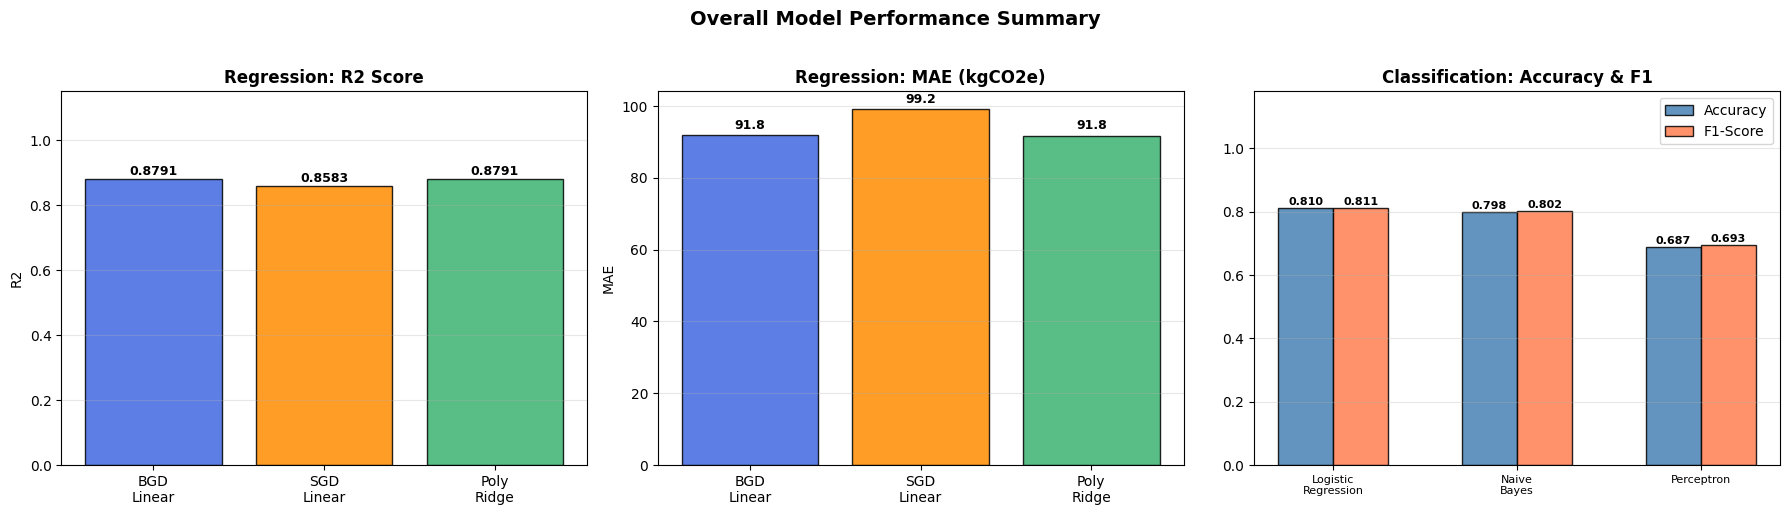

In [ ]:
# Consolidated metrics table
print(f"{'Model':<32} {'MAE':>10} {'MSE':>14} {'R2':>8}")
for label, mae, mse, r2 in [
    ("BGD Linear Regression",     mae_bgd,   mse_bgd,   r2_bgd),
    ("SGD Linear Regression",     mae_sgd,   mse_sgd,   r2_sgd),
    ("Poly + Ridge L2",           mae_ridge, mse_ridge, r2_ridge),
    ("Poly + Lasso L1",           mae_lasso, mse_lasso, r2_lasso),
]:
    print(f"{label:<32} {mae:>10.2f} {mse:>14.2f} {r2:>8.4f}")

print(f"{'Model':<28} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1-Score':>10}")

for name, r in results_cls.items():
    print(f"{name:<28} {r['accuracy']:>10.4f} {r['precision']:>11.4f} "
          f"{r['recall']:>9.4f} {r['f1']:>10.4f}")

# Final summary radar / bar chart
all_reg_models = ['BGD\nLinear', 'SGD\nLinear', 'Poly\nRidge']
all_r2  = [r2_bgd, r2_sgd, r2_ridge]
all_mae = [mae_bgd, mae_sgd, mae_ridge]

cls_model_names = list(results_cls.keys())
cls_f1 = [results_cls[n]['f1'] for n in cls_model_names]
cls_acc = [results_cls[n]['accuracy'] for n in cls_model_names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_clr_reg = ['royalblue', 'darkorange', 'mediumseagreen']
bar_clr_cls = ['steelblue', 'coral', 'goldenrod']

# R2 bars for regression
bars = axes[0].bar(all_reg_models, all_r2, color=bar_clr_reg, alpha=0.85, edgecolor='black')
for b, v in zip(bars, all_r2):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title('Regression: R2 Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R2'); axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', alpha=0.3)

# MAE bars for regression
bars = axes[1].bar(all_reg_models, all_mae, color=bar_clr_reg, alpha=0.85, edgecolor='black')
for b, v in zip(bars, all_mae):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 1,
                 f'{v:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Regression: MAE (kgCO2e)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('MAE'); axes[1].grid(axis='y', alpha=0.3)

# F1 + Accuracy bars for classifiers
x_pos = np.arange(len(cls_model_names))
w = 0.3
r1 = axes[2].bar(x_pos - w/2, cls_acc, w, label='Accuracy', color='steelblue', alpha=0.85, edgecolor='black')
r2_ = axes[2].bar(x_pos + w/2, cls_f1,  w, label='F1-Score', color='coral',     alpha=0.85, edgecolor='black')
for b, v in list(zip(r1, cls_acc)) + list(zip(r2_, cls_f1)):
    axes[2].text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_title('Classification: Accuracy & F1', fontsize=12, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([n.replace(' ', '\n') for n in cls_model_names], fontsize=8)
axes[2].set_ylim(0, 1.18); axes[2].legend(); axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Overall Model Performance Summary', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Key Takeaways:

Dataset
  1) 5 input features: Nitrogen_kg_ha, Irrigation_Water_mm,
    Avg_Temperature_C, Rainfall_mm, Humidity_%
  2) Target: Total_GHG_kgCO2e  (CO2/CH4/N2O components excluded
    to avoid data leakage)

EDA
  1) Nitrogen application is the strongest predictor of GHG emissions.
  2) Flood irrigation + rice = highest emissions (methane-driven).
  3) Reduced-input (Counterfactual) always beats Baseline in emissions.

Linear Regression
  1) BGD: smooth convergence, deterministic, full-batch updates.
  2) SGD: noisy convergence, sample-by-sample updates, faster iteration.
  3) Both reach comparable final R2; SGD is preferred for large datasets.

Polynomial Regression + Regularisation
  1) Degree-2 expansion captures nonlinear feature interactions.
  2) Ridge (L2): uniform coefficient shrinkage, no feature elimination.
  3) Lasso (L1): sparse solution – many cross-terms zeroed out, improving
    interpretability and reducing overfitting.
  4) Both polynomial models typically outperform linear models (higher R2,
    lower MAE) when nonlinear structure is present.

Classification
  1) Tertile labelling gives balanced Low / Medium / High classes.
  2) Logistic Regression generally achieves the highest accuracy and F1.
  3) Naive Bayes is fast but assumes feature independence (violated here).
  4) Perceptron is simple but sensitive to class overlap.
  5) Classification is more actionable for policy decisions; it trades
    regression precision for interpretable, discrete emission categories.